In [1]:
#Nombre: Yupari Figueroa Rosa Isela
#dataset: https://www.kaggle.com/datasets/jtennis/spctornado?
#variable:  predecir la magnitud de tornados

# utilizado para manejos de directorios y rutas
import os

# Computacion vectorial y cientifica para python
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

# Para generar datasets sintéticos y preprocesar
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures

# Fijar semilla para reproducibilidad
np.random.seed(42)


In [3]:
import pandas as pd
data = pd.read_csv('/content/Tornadoes_SPC_1950to2015.csv')

In [4]:
display(data)

,om,yr,mo,dy,date,time,tz,st,stf,stn,...,fat,loss,closs,slat,slon,elat,elon,len,wid,fc
0,1,1950,1,3,1/3/1950,11:00:00,3,MO,29,1,...,0,6.00,0.0,38.77,-90.22,38.83,-90.03,9.50,150,0
1,2,1950,1,3,1/3/1950,11:55:00,3,IL,17,2,...,0,5.00,0.0,39.10,-89.30,39.12,-89.23,3.60,130,0
2,3,1950,1,3,1/3/1950,16:00:00,3,OH,39,1,...,0,4.00,0.0,40.88,-84.58,0.00,0.00,0.10,10,0
3,4,1950,1,13,1/13/1950,5:25:00,3,AR,5,1,...,1,3.00,0.0,34.40,-94.37,0.00,0.00,0.60,17,0
4,5,1950,1,25,1/25/1950,19:30:00,3,MO,29,2,...,0,5.00,0.0,37.60,-90.68,37.63,-90.65,2.30,300,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60109,607506,2015,12,28,12/28/2015,3:20:00,3,LA,22,0,...,0,0.00,0.0,30.08,-90.54,30.08,-90.53,0.60,150,0
60110,613277,2015,12,28,12/28/2015,4:46:00,3,AR,5,0,...,0,0.05,0.0,34.70,-90.92,34.78,-90.90,5.75,40,0
60111,607307,2015,12,28,12/28/2015,5:43:00,3,MS,28,0,...,0,0.10,0.0,31.54,-89.53,31.61,-89.49,5.59,100,0
60112,612738,2015,12,28,12/28/2015,8:30:00,3,FL,12,0,...,0,0.01,0.0,30.76,-87.24,30.77,-87.23,0.78,75,0


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60114 entries, 0 to 60113
Data columns (total 22 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   om      60114 non-null  int64  
 1   yr      60114 non-null  int64  
 2   mo      60114 non-null  int64  
 3   dy      60114 non-null  int64  
 4   date    60114 non-null  object 
 5   time    60114 non-null  object 
 6   tz      60114 non-null  int64  
 7   st      60114 non-null  object 
 8   stf     60114 non-null  int64  
 9   stn     60114 non-null  int64  
 10  mag     60114 non-null  int64  
 11  inj     60114 non-null  int64  
 12  fat     60114 non-null  int64  
 13  loss    60114 non-null  float64
 14  closs   60114 non-null  float64
 15  slat    60114 non-null  float64
 16  slon    60114 non-null  float64
 17  elat    60114 non-null  float64
 18  elon    60114 non-null  float64
 19  len     60114 non-null  float64
 20  wid     60114 non-null  int64  
 21  fc      60114 non-null  int64  
dty

In [6]:
#variables categoricas
columnas_categoricas = data.select_dtypes(include=['object']).columns

In [7]:
from sklearn.preprocessing import LabelEncoder
from datetime import datetime
#Procesamiento de frases o palabras
for columna in columnas_categoricas:
  le = LabelEncoder()
  data[columna] = le.fit_transform(data[columna])

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60114 entries, 0 to 60113
Data columns (total 22 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   om      60114 non-null  int64  
 1   yr      60114 non-null  int64  
 2   mo      60114 non-null  int64  
 3   dy      60114 non-null  int64  
 4   date    60114 non-null  int64  
 5   time    60114 non-null  int64  
 6   tz      60114 non-null  int64  
 7   st      60114 non-null  int64  
 8   stf     60114 non-null  int64  
 9   stn     60114 non-null  int64  
 10  mag     60114 non-null  int64  
 11  inj     60114 non-null  int64  
 12  fat     60114 non-null  int64  
 13  loss    60114 non-null  float64
 14  closs   60114 non-null  float64
 15  slat    60114 non-null  float64
 16  slon    60114 non-null  float64
 17  elat    60114 non-null  float64
 18  elon    60114 non-null  float64
 19  len     60114 non-null  float64
 20  wid     60114 non-null  int64  
 21  fc      60114 non-null  int64  
dty

In [9]:
# En caso de identificar la "y" en otra posicion, no ultima
columnas_seleccionadas = list(range(0, 9)) + list(range(11, 21))
X = data.iloc[:, columnas_seleccionadas]
y = data.iloc[:, 10]
m = y.size

In [10]:
print(X)
print('*'*25)
print(y)

           om    yr  mo  dy  date  time  tz  st  stf  inj  fat  loss  closs  \
0           1  1950   1   3   243   120   3  24   29    3    0  6.00    0.0   
1           2  1950   1   3   243   175   3  14   17    3    0  5.00    0.0   
2           3  1950   1   3   243   420   3  35   39    1    0  4.00    0.0   
3           4  1950   1  13    43  1158   3   2    5    1    1  3.00    0.0   
4           5  1950   1  25   186   630   3  24   29    5    0  5.00    0.0   
...       ...   ...  ..  ..   ...   ...  ..  ..  ...  ...  ...   ...    ...   
60109  607506  2015  12  28  1549  1038   3  18   22    0    0  0.00    0.0   
60110  613277  2015  12  28  1549  1122   3   2    5    0    0  0.05    0.0   
60111  607307  2015  12  28  1549  1176   3  25   28    0    0  0.10    0.0   
60112  612738  2015  12  28  1549  1340   3   9   12    0    0  0.01    0.0   
60113  612739  2015  12  28  1549   418   3  27   37    0    0  0.05    0.0   

        slat   slon   elat   elon   len  wid  
0   

In [11]:
# Importar libreria para dividir entrenamiento y prueba
from sklearn.model_selection import train_test_split
# Dividir en conjunto de entrenamiento y prueba

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")


Train: (48091, 19), Test: (12023, 19)


In [12]:
# Normalizar características (usar media y desviación estándar del conjunto de entrenamiento)

def feature_normalize(X, mu=None, sigma=None):
    X_norm = X.copy().astype(float)

    if mu is None:
        mu = np.mean(X_norm, axis=0)
    if sigma is None:
        sigma = np.std(X_norm, axis=0)
        # Evitar división por cero
        sigma[sigma == 0] = 1.0

    X_norm = (X_norm - mu) / sigma
    return X_norm, mu, sigma


In [13]:
# Normalizar características

X_train_norm, mu, sigma = feature_normalize(X_train)
X_test_norm, _, _ = feature_normalize(X_test, mu, sigma)

# Añade columna de 1s para theta0
m_train = X_train_norm.shape[0]
m_test = X_test_norm.shape[0]

X_train_bias = np.concatenate([np.ones((m_train, 1)), X_train_norm], axis=1)
X_test_bias = np.concatenate([np.ones((m_test, 1)), X_test_norm], axis=1)

print(f"X_train_bias shape: {X_train_bias.shape}")
print(f"X_test_bias shape: {X_test_bias.shape}")


X_train_bias shape: (48091, 20)
X_test_bias shape: (12023, 20)


In [34]:
# Funciones auxiliares

def mean_absolute_error(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

In [14]:
# Definir funciones de costo y descenso por gradiente para regresión lineal

def compute_cost(X, y, theta):
    m = len(y)
    predictions = X.dot(theta)
    error = predictions - y
    return (1 / (2 * m)) * np.dot(error, error)


def gradient_descent(X, y, theta, alpha, num_iters):
    m = len(y)
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        error = X.dot(theta) - y
        theta = theta - (alpha / m) * (X.T.dot(error))
        J_history.append(compute_cost(X, y, theta))

    return theta, np.array(J_history)


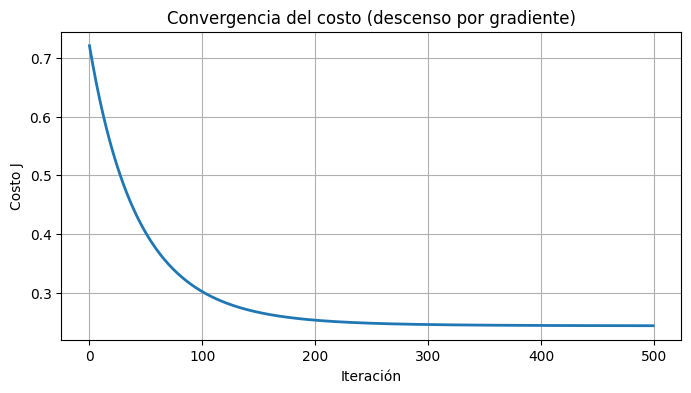

Theta aprendido (primeros 10 valores): [ 0.790513    0.01790376 -0.34734206  0.00579965 -0.00968539 -0.08656168
  0.03115379  0.00121621  0.00221664 -0.00161675]
Costo final: 0.24432942355337925


In [22]:
# Librerias para graficación (trazado de gráficos)
from matplotlib import pyplot
# Entrenamiento: regresión lineal multivariable por descenso por gradiente

alpha = 0.01
num_iters = 500

theta_init = np.zeros(X_train_bias.shape[1])

theta_gd, J_history = gradient_descent(X_train_bias, y_train, theta_init, alpha, num_iters)

# Gráfica de convergencia de costo
pyplot.figure(figsize=(8, 4))
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.title('Convergencia del costo (descenso por gradiente)')
pyplot.xlabel('Iteración')
pyplot.ylabel('Costo J')
pyplot.grid(True)
pyplot.show()

print('Theta aprendido (primeros 10 valores):', theta_gd[:10])
print('Costo final:', J_history[-1])


In [24]:
# Evaluación del modelo lineal en el conjunto de prueba

y_pred_test = X_test_bias.dot(theta_gd)

mae_lin = mean_absolute_error(y_test, y_pred_test)

print(f"MAE (lineal - gradiente): {mae_lin:.4f}")

# Mostrar 100 predicciones frente a valores reales
n_show = 100
sample_idx = np.random.choice(m_test, size=n_show, replace=False)
comparison = pd.DataFrame({
    "y_real": y_test.iloc[sample_idx],
    "y_pred": y_pred_test[sample_idx],
})

print("\nPrimeras 10 predicciones (de 100):")
print(comparison.head(10))

MAE (lineal - gradiente): 0.5594

Primeras 10 predicciones (de 100):
       y_real    y_pred
11917       2  1.147810
39429       1  0.891460
55188       1  0.376335
27427       1  0.641108
51834       0  0.170995
55182       2  2.955450
803         1  1.231234
23622       2  0.329273
40966       0  0.463868
6994        0  0.962644


In [26]:
# Calcular theta por la ecuación normal (sin normalización adicional)

# Usamos X_train_bias y y_train directamente

def normal_equation(X, y):
    return np.linalg.pinv(X.T.dot(X)).dot(X.T).dot(y)

theta_normal = normal_equation(X_train_bias, y_train)

# Evaluación en el conjunto de prueba

y_pred_normal = X_test_bias.dot(theta_normal)

mae_normal = mean_absolute_error(y_test, y_pred_normal)

print('Theta (ecuación normal) - primeros 10 valores:', theta_normal[:10])
print(f"MAE (normal): {mae_normal:.4f}")



Theta (ecuación normal) - primeros 5 valores: [ 0.79574141  0.0310393  -0.37789556  0.00739503 -0.01047486 -0.08749605
  0.03072521  0.00209147  0.06106641 -0.06118524]
MAE (normal): 0.5586


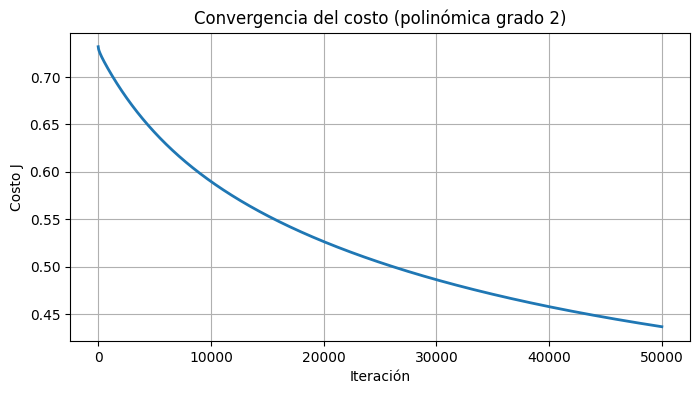

MAE (polinómica): 0.7183


In [31]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures

degree = 2
poly = PolynomialFeatures(degree=degree, include_bias=False)

X_train_poly = poly.fit_transform(X_train_norm)
X_test_poly = poly.transform(X_test_norm)

# Añadir término de sesgo
X_train_poly_bias = np.concatenate([np.ones((X_train_poly.shape[0], 1)), X_train_poly], axis=1)
X_test_poly_bias = np.concatenate([np.ones((X_test_poly.shape[0], 1)), X_test_poly], axis=1)

# Entrenar con descenso por gradiente
alpha_poly = 0.000001
num_iters_poly = 50000
theta_poly_init = np.zeros(X_train_poly_bias.shape[1])
theta_poly, J_history_poly = gradient_descent(
    X_train_poly_bias, y_train, theta_poly_init, alpha_poly, num_iters_poly
)

# Graficar costo
plt.figure(figsize=(8, 4))
plt.plot(np.arange(len(J_history_poly)), J_history_poly, lw=2)
plt.title('Convergencia del costo (polinómica grado 2)')
plt.xlabel('Iteración')
plt.ylabel('Costo J')
plt.grid(True)
plt.show()

# Evaluación
y_pred_poly = X_test_poly_bias.dot(theta_poly)

mae_poly = mean_absolute_error(y_test, y_pred_poly)

print(f"MAE (polinómica): {mae_poly:.4f}")

In [33]:
# Mostrar predicciones del modelo polinómico contra los valores reales

n_show = 100
sample_idx = np.random.choice(m_test, size=n_show, replace=False)
comparison_poly = pd.DataFrame({
    "y_real": y_test.iloc[sample_idx],
    "y_pred_poly": y_pred_poly[sample_idx],
})

print(comparison_poly.head(10))

       y_real  y_pred_poly
53799       1     0.366736
15738       1     0.391475
58959       1     0.835228
38948       0     0.263262
22220       0     0.228031
32498       0     0.252796
1357        1     0.510008
9877        2     0.531576
37345       0     0.252475
22342       2     0.377303
